In [1]:
import pandas as pd
import pymysql

# Conecta a MySQL
conn = pymysql.connect(
    host='localhost', #host del servidor
    user='usr', #usuario del servidor 
    password='contraseña', #contraseña del servidor sql
    database='banco_aml',
    unix_socket='ruta', #ruta del socker
    autocommit=True,
    charset='char' #charset del servidor
)

# Carga los montos
query = "SELECT amount FROM transacciones_paysim"
df = pd.read_sql(query, conn)
conn.close()

# Calcula la mediana
mediana = df['amount'].median()
media = df['amount'].mean()

print(f"Media: ${media:,.2f}")
print(f"Mediana: ${mediana:,.2f}")
print(f"Relación Media/Mediana: {media/mediana:.2f}x")


/tmp/ipykernel_13242/3841457989.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Media: $179,861.90
Mediana: $74,871.94
Relación Media/Mediana: 2.40x


In [6]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("ANÁLISIS DE DISTRIBUCIÓN DE MONTOS - PAYSIM")
print("="*60)

# ===== FUNCIÓN PARA CONECTAR =====
def conectar_mysql():
    return pymysql.connect(
        host='localhost', #host del servidor
        user='usr', #usuario del servidor 
        password='contraseña', #contraseña del servidor sql
        database='banco_aml',
        unix_socket='ruta', #ruta del socker
        autocommit=True,
        charset='char' #charset del servidor
        connect_timeout=60
    )

# ===== CARGA LOS DATOS =====
try:
    print("Conectando a MySQL...")
    conn = conectar_mysql()
    
    print("Cargando datos de transacciones...")
    query = "SELECT amount, isFraud FROM transacciones_paysim"
    df = pd.read_sql(query, conn)
    conn.close()
    
    print(f"Datos cargados: {len(df):,} transacciones")
    
except Exception as e:
    print(f"Error al cargar datos: {e}")
    print("Intentando reconectar...")
    time.sleep(2)
    conn = conectar_mysql()
    df = pd.read_sql(query, conn)
    conn.close()
    print(f"Datos cargados: {len(df):,} transacciones")



ANÁLISIS DE DISTRIBUCIÓN DE MONTOS - PAYSIM
Conectando a MySQL...
Cargando datos de transacciones...


/tmp/ipykernel_15546/1518916085.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Datos cargados: 6,362,620 transacciones



 ESTADÍSTICAS DE MONTOS
Media: $179,861.90
Mediana: $74,871.94
Desviación Estándar: $603,858.23
Percentil 95: $518,634.20
Percentil 99: $1,615,979.47
Mínimo: $0.00
Máximo: $92,445,516.64
Relación Media/Mediana: 2.40x


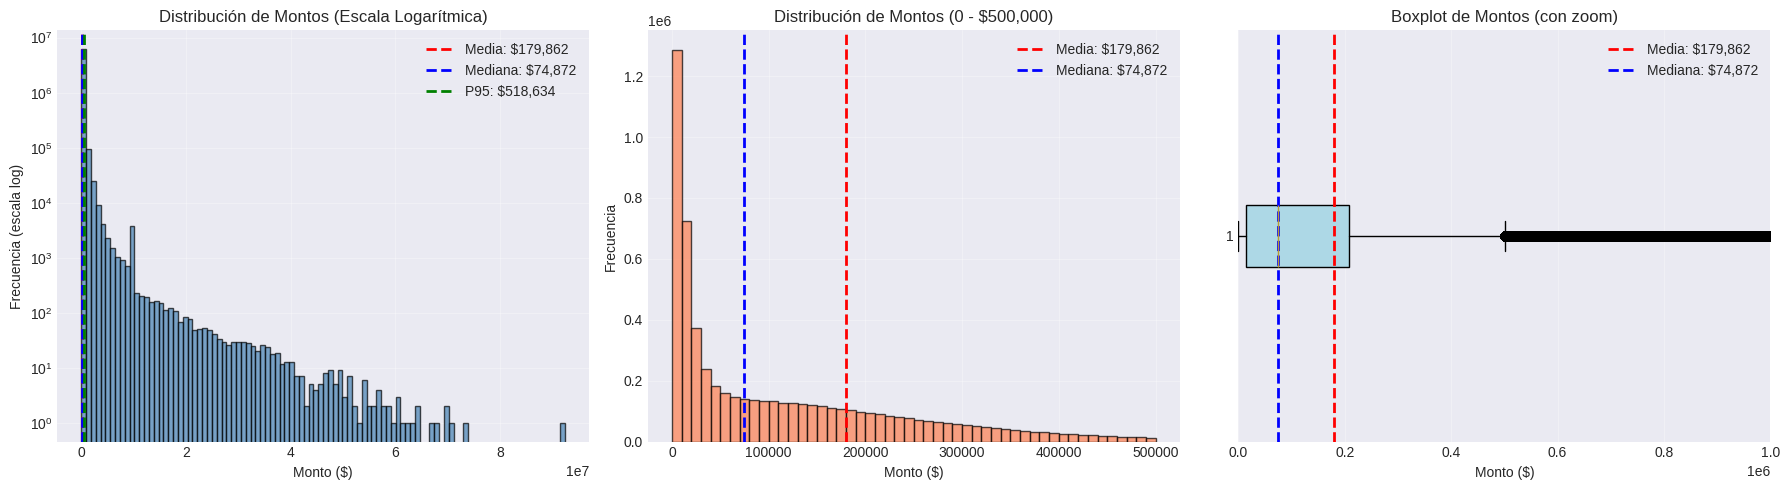

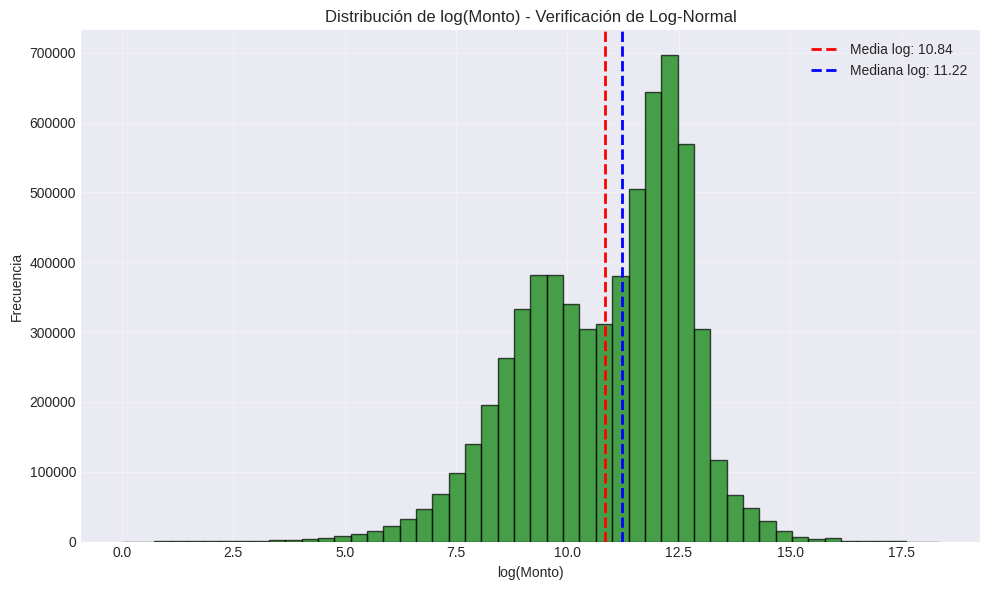

/tmp/ipykernel_15546/226382601.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraude_por_rango = df.groupby('rango')['isFraud'].sum().reset_index()
/tmp/ipykernel_15546/226382601.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_por_rango = df.groupby('rango')['isFraud'].count().reset_index()


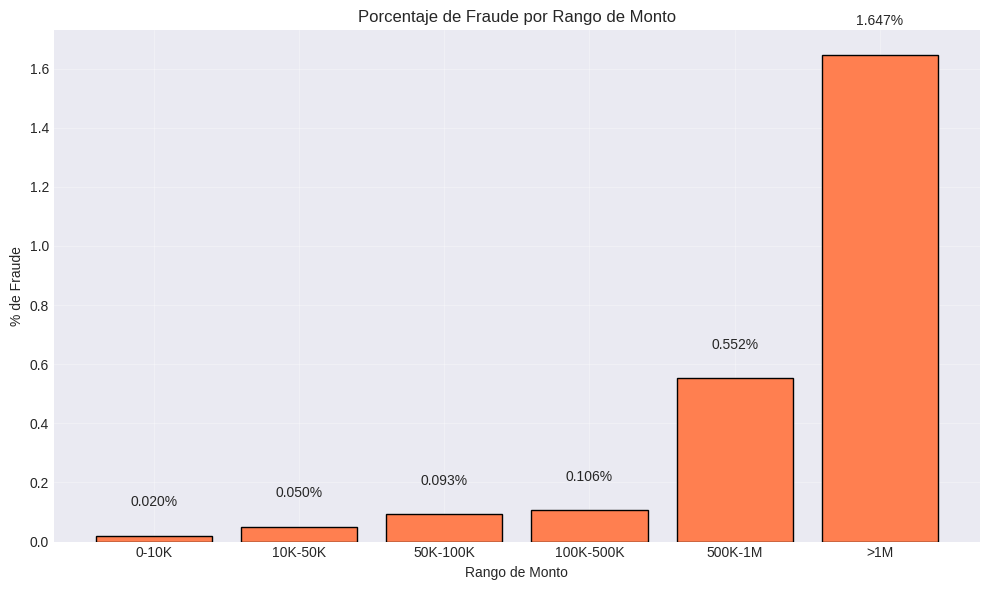


RESUMEN EJECUTIVO
1. Distribución: Los montos siguen una distribución LOG-NORMAL (no gaussiana)
2. Media: $179,861.90 | Mediana: $74,871.94 | Ratio: 2.40x
3. El 50.0% de transacciones superan la mediana
4. El 29.5% de transacciones superan la media


In [7]:
# ===== ESTADÍSTICAS BÁSICAS =====
media = df['amount'].mean()
mediana = df['amount'].median()
percentil_95 = df['amount'].quantile(0.95)
percentil_99 = df['amount'].quantile(0.99)
std = df['amount'].std()

print("\n" + "="*60)
print(" ESTADÍSTICAS DE MONTOS")
print("="*60)
print(f"Media: ${media:,.2f}")
print(f"Mediana: ${mediana:,.2f}")
print(f"Desviación Estándar: ${std:,.2f}")
print(f"Percentil 95: ${percentil_95:,.2f}")
print(f"Percentil 99: ${percentil_99:,.2f}")
print(f"Mínimo: ${df['amount'].min():,.2f}")
print(f"Máximo: ${df['amount'].max():,.2f}")
print(f"Relación Media/Mediana: {media/mediana:.2f}x")

# =============================================
# GRÁFICA 1: HISTOGRAMA CON AJUSTE LOG-NORMAL
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1.1 Histograma (escala logarítmica en Y)
axes[0].hist(df['amount'], bins=100, edgecolor='black', alpha=0.7, log=True, color='steelblue')
axes[0].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: ${media:,.0f}')
axes[0].axvline(mediana, color='blue', linestyle='--', linewidth=2, label=f'Mediana: ${mediana:,.0f}')
axes[0].axvline(percentil_95, color='green', linestyle='--', linewidth=2, label=f'P95: ${percentil_95:,.0f}')
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia (escala log)')
axes[0].set_title('Distribución de Montos (Escala Logarítmica)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 1.2 Histograma con zoom (0 - 500,000)
df_zoom = df[df['amount'] <= 500000]
axes[1].hist(df_zoom['amount'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: ${media:,.0f}')
axes[1].axvline(mediana, color='blue', linestyle='--', linewidth=2, label=f'Mediana: ${mediana:,.0f}')
axes[1].set_xlabel('Monto ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Montos (0 - $500,000)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 1.3 Boxplot
axes[2].boxplot(df['amount'], vert=False, patch_artist=True, 
                boxprops=dict(facecolor='lightblue'))
axes[2].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: ${media:,.0f}')
axes[2].axvline(mediana, color='blue', linestyle='--', linewidth=2, label=f'Mediana: ${mediana:,.0f}')
axes[2].set_xlabel('Monto ($)')
axes[2].set_title('Boxplot de Montos (con zoom)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 1000000)

plt.tight_layout()
plt.savefig('distribucion_montos.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# GRÁFICA 2: VERIFICACIÓN DE LOG-NORMAL
# =============================================
fig = plt.figure(figsize=(10, 6))
log_amount = np.log1p(df['amount'])
plt.hist(log_amount, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.axvline(np.mean(log_amount), color='red', linestyle='--', linewidth=2, 
            label=f'Media log: {np.mean(log_amount):.2f}')
plt.axvline(np.median(log_amount), color='blue', linestyle='--', linewidth=2, 
            label=f'Mediana log: {np.median(log_amount):.2f}')
plt.xlabel('log(Monto)')
plt.ylabel('Frecuencia')
plt.title('Distribución de log(Monto) - Verificación de Log-Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('log_montos.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# GRÁFICA 3: FRAUDE POR RANGO DE MONTO
# =============================================
bins = [0, 10000, 50000, 100000, 500000, 1000000, 5000000]
labels = ['0-10K', '10K-50K', '50K-100K', '100K-500K', '500K-1M', '>1M']
df['rango'] = pd.cut(df['amount'], bins=bins, labels=labels)

fraude_por_rango = df.groupby('rango')['isFraud'].sum().reset_index()
total_por_rango = df.groupby('rango')['isFraud'].count().reset_index()

fraude_por_rango['total'] = total_por_rango['isFraud']
fraude_por_rango['pct'] = fraude_por_rango['isFraud'] / fraude_por_rango['total'] * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(fraude_por_rango['rango'], fraude_por_rango['pct'], 
               color='coral', edgecolor='black')
plt.xlabel('Rango de Monto')
plt.ylabel('% de Fraude')
plt.title('Porcentaje de Fraude por Rango de Monto')
plt.grid(True, alpha=0.3)

# Añadir etiquetas de valor
for bar, pct in zip(bars, fraude_por_rango['pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{pct:.3f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fraude_por_rango.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# RESUMEN EJECUTIVO
# =============================================
print("\n" + "="*60)
print("RESUMEN EJECUTIVO")
print("="*60)
print(f"1. Distribución: Los montos siguen una distribución LOG-NORMAL (no gaussiana)")
print(f"2. Media: ${media:,.2f} | Mediana: ${mediana:,.2f} | Ratio: {media/mediana:.2f}x")
print(f"3. El {len(df[df['amount'] > mediana])/len(df)*100:.1f}% de transacciones superan la mediana")
print(f"4. El {len(df[df['amount'] > media])/len(df)*100:.1f}% de transacciones superan la media")

# FEATURES CREADAS A PARTIR DE LA VISUALIZACIÓN DE DATOS Y CONSULTAS PARA HACER LAS PREDICCIÓNES

CREATE TABLE fraud_features AS

SELECT 
    
    id,
    step,
    type,
    amount,
    nameOrig,
    nameDest,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,
    isFraud,
    isFlaggedFraud,
    
    CASE WHEN amount > 518634.20 THEN 1 ELSE 0 END AS monto_alto,
    CASE WHEN type IN ('TRANSFER', 'CASH_OUT') THEN 1 ELSE 0 END AS tipo_riesgoso,
    CASE WHEN oldbalanceOrg > 0 THEN amount / oldbalanceOrg ELSE 0 END AS ratio_gasto_saldo,
    CASE WHEN newbalanceOrig = 0 THEN 1 ELSE 0 END AS saldo_cero,
    oldbalanceOrg - newbalanceOrig AS cambio_saldo,
    CASE WHEN oldbalanceDest = 0 THEN 1 ELSE 0 END AS destino_saldo_cero,
    amount / 74871.94 AS monto_relativo,
    CASE 
        WHEN amount > 1615979.47 THEN 100
        WHEN amount > 518634.20 THEN 75
        WHEN amount > 74871.94 * 3 THEN 50
        WHEN amount > 74871.94 THEN 25
        ELSE 0
    END AS monto_riesgo_score,
  
    CASE WHEN type = 'PAYMENT'  THEN 1 ELSE 0 END AS es_PAYMENT,
    CASE WHEN type = 'TRANSFER' THEN 1 ELSE 0 END AS es_TRANSFER,
    CASE WHEN type = 'CASH_OUT' THEN 1 ELSE 0 END AS es_CASH_OUT,
    CASE WHEN type = 'CASH_IN'  THEN 1 ELSE 0 END AS es_CASH_IN,
    CASE WHEN type = 'DEBIT'    THEN 1 ELSE 0 END AS es_DEBIT

FROM transacciones_paysim;

### 2. Tabla Procesada: `fraud_features`
**Descripción:** Tabla con las **14 features de riesgo** creadas a partir de la tabla original.
**Propósito:** Contiene los KPIs de riesgo para alimentar el modelo XGBoost.

| Feature | Tipo | Descripción | Lógica de Negocio (KPI) |
| :--- | :--- | :--- | :--- |
| `id` | INT | Identificador de la transacción. | Referencia a la tabla original. |
| **Features Base (8)** | | | |
| `monto_alto` | INT | 1 si `amount > $518,634` (Percentil 95). | **KPI de Riesgo:** Detecta transacciones de valor extremadamente alto. |
| `tipo_riesgoso` | INT | 1 si `type` es `TRANSFER` o `CASH_OUT`. | **KPI de Comportamiento:** Marca los tipos de operación más usados para lavar dinero. |
| `ratio_gasto_saldo` | DECIMAL | `amount / oldbalanceOrg`. | **KPI de Consistencia:** Mide si el cliente gasta más de lo que tiene (inconsistencia financiera). |
| `saldo_cero` | INT | 1 si `newbalanceOrig == 0`. | **KPI de Vaciado:** Indica si la cuenta de origen quedó en cero (señal de cuenta "puente"). |
| `cambio_saldo` | DECIMAL | `oldbalanceOrg - newbalanceOrig`. | **KPI de Impacto:** Cantidad real de dinero que salió de la cuenta. |
| `destino_saldo_cero` | INT | 1 si `oldbalanceDest == 0`. | **KPI de Destino:** Indica si el destinatario tiene una cuenta vacía (cuenta "fantasma"). |
| `monto_relativo` | DECIMAL | `amount / 74,871.94` (Mediana global). | **KPI de Normalización:** Cuánto se desvía el monto del comportamiento "normal" del banco. |
| `monto_riesgo_score` | INT | Score de 0 a 100 según percentiles (P95, P99). | **KPI de Severidad:** Escala de riesgo basada en el monto. |
| **One-Hot Encoding (5)** | | | |
| `es_PAYMENT` | INT | 1 si `type` es `PAYMENT`. | **KPI de Canal:** Permite al modelo aprender patrones específicos de este tipo. |
| `es_TRANSFER` | INT | 1 si `type` es `TRANSFER`. | **KPI de Canal:** Permite al modelo aprender patrones específicos de este tipo. |
| `es_CASH_OUT` | INT | 1 si `type` es `CASH_OUT`. | **KPI de Canal:** Permite al modelo aprender patrones específicos de este tipo. |
| `es_CASH_IN` | INT | 1 si `type` es `CASH_IN`. | **KPI de Canal:** Permite al modelo aprender patrones específicos de este tipo. |
| `es_DEBIT` | INT | 1 si `type` es `DEBIT`. | **KPI de Canal:** Permite al modelo aprender patrones específicos de este tipo. |
| **Feature Estrella (1)** | | | |
| `es_transferencia_total` | INT | 1 si `type = 'TRANSFER'` y `amount == oldbalanceOrg`. | **KPI de Cuenta Puente:** 🚀 **La feature más importante.** Detecta la "firma digital" del lavado de dinero (transferir TODO el saldo). |

---

### 3. Resumen de Features y su Impacto en el Negocio

| Feature | KPI de Negocio | ¿Qué mide? |
| :--- | :--- | :--- |
| `es_transferencia_total` | Detección de Lavado | Si el cliente vacía su cuenta en una sola transferencia. |
| `cambio_saldo` | Impacto Económico | Cuánto dinero se mueve realmente. |
| `ratio_gasto_saldo` | Consistencia Financiera | Si el cliente gasta más de lo que tiene. |
| `monto_alto` | Alerta Regulatoria | Si supera los umbrales de la CNBV. |
| `saldo_cero` | Vaciado de Cuenta | Si la cuenta queda en cero (señal de "cuenta puente"). |